#  Tomato Leaf Disease Classification — AI Final Assignment

## Dataset Overview
This project uses the **PlantVillage Tomato Subset** with **10 tomato disease/healthy classes**:

| # | Class Name | Description |
|---|-----------|-------------|
| 1 | Tomato_Bacterial_spot | Bacterial infection causing dark, water-soaked spots |
| 2 | Tomato_Early_blight | Fungal disease with dark concentric ring lesions |
| 3 | Tomato_Late_blight | Aggressive fungal/oomycete disease, large brown patches |
| 4 | Tomato_Leaf_Mold | Fungal disease, yellowish-green to olive-brown patches |
| 5 | Tomato_Septoria_leaf_spot | Small circular spots with dark borders |
| 6 | Tomato_Spider_mites_Two_spotted_spider_mite | Pest causing stippled, yellowed leaves |
| 7 | Tomato__Target_Spot | Concentric circular target-like lesions |
| 8 | Tomato__Tomato_YellowLeaf__Curl_Virus | Viral disease, yellowing and upward leaf curl |
| 9 | Tomato__Tomato_mosaic_virus | Viral disease, mosaic-like yellow-green patterns |
| 10 | Tomato_healthy | Healthy, disease-free tomato leaf |

> **Total Tomato Subsets Used: 10** — all 10 tomato folders from PlantVillage.

---
## Project Pipeline
```
Dataset Extraction → EDA & Visualization → Preprocessing & Augmentation
     ↓
Part A: Custom CNNs
  Step 1: Baseline CNN  (3 Conv layers)
  Step 2: Deeper CNN    (6 Conv layers + BatchNorm + Dropout)
  Step 3: Optimizer Comparison (SGD vs Adam)
  Step 4: Ablation Study (No Dropout)
     ↓
Part B: Transfer Learning (MobileNetV2)
  Phase 1: Feature Extraction (frozen base)
  Phase 2: Fine-Tuning (last 50 layers unfrozen)
     ↓
Final Comparison: Baseline vs Deeper vs MobileNetV2
```

---
### 🛠️ Key Fixes in This Version
1. **Confusion matrix bug fixed** — validation generator now uses `shuffle=False`, so predictions
   and `val_gen.classes` line up row-for-row.
2. **Class weights added** — handles imbalance (Mosaic ~370 imgs vs YellowCurl 3000+).
3. **Learning rate scheduling** — `ReduceLROnPlateau` cuts LR when validation plateaus.
4. **Stronger augmentation** — better generalization on real-world leaf images.
5. **MobileNetV2 fine-tuning extended** — unfreezes last 50 layers (was 30) for better adaptation.


## Step 1 — Mount Google Drive & Extract Dataset

Mount Drive once, extract the zip only if it isn't already extracted.
Idempotent so re-runs are fast.


In [2]:
# STEP 1: Mount Google Drive and extract the dataset
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path     = '/content/drive/MyDrive/AIML/assignment/plantHealth.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extracted successfully!")
else:
    print("Already extracted, skipping...")

print("\nFolders found:")
for f in os.listdir(extract_path):
    print(" -", f)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted successfully!

Folders found:
 - plantvillage
 - PlantVillage


## Step 2 — Import Libraries

All imports grouped at the top so dependencies are obvious. Adding
`ReduceLROnPlateau` for LR scheduling and `compute_class_weight` to handle imbalance.


In [3]:
# STEP 2: Import all required libraries
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, Input)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")
print(f"   TensorFlow version: {tf.__version__}")
print(f"   GPU available: {tf.config.list_physical_devices('GPU')}")


All libraries imported successfully!
   TensorFlow version: 2.20.0
   GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 3 — Define the 10 Tomato Classes

Hardcoding the class names keeps the order reproducible across all generators,
metrics, and plots — and ensures we don't pick up pepper/potato folders by accident.


In [4]:
# STEP 3: Define all 10 Tomato classes
BASE_DIR = '/content/dataset/PlantVillage'

TOMATO_CLASSES = [
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy',
]

CLASS_DIRS = {cls: os.path.join(BASE_DIR, cls) for cls in TOMATO_CLASSES}
NUM_CLASSES = len(CLASS_DIRS)

# Short names for plots (the full names are too long for x-axis ticks)
cn_short = [
    'Bacterial Spot', 'Early Blight', 'Late Blight',
    'Leaf Mold', 'Septoria Spot', 'Spider Mites',
    'Target Spot', 'Yellow Curl', 'Mosaic Virus', 'Healthy'
]

print(f"{NUM_CLASSES} Tomato classes defined:")
for cls in TOMATO_CLASSES:
    print(f"   - {cls}")


10 Tomato classes defined:
   - Tomato_Bacterial_spot
   - Tomato_Early_blight
   - Tomato_Late_blight
   - Tomato_Leaf_Mold
   - Tomato_Septoria_leaf_spot
   - Tomato_Spider_mites_Two_spotted_spider_mite
   - Tomato__Target_Spot
   - Tomato__Tomato_YellowLeaf__Curl_Virus
   - Tomato__Tomato_mosaic_virus
   - Tomato_healthy


## Step 4 — EDA: Class Distribution & Sample Images

Counting images per class first reveals **class imbalance** — which is exactly why
we'll add class weights during training in Step 5.


Dataset Description:
   PlantVillage Tomato Dataset — 10 disease/healthy classes

Total images in dataset: 16011

Class Distribution:
   Tomato_Bacterial_spot: 2127 images
   Tomato_Early_blight: 1000 images
   Tomato_Late_blight: 1909 images
   Tomato_Leaf_Mold: 952 images
   Tomato_Septoria_leaf_spot: 1771 images
   Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
   Tomato__Target_Spot: 1404 images
   Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
   Tomato__Tomato_mosaic_virus: 373 images
   Tomato_healthy: 1591 images


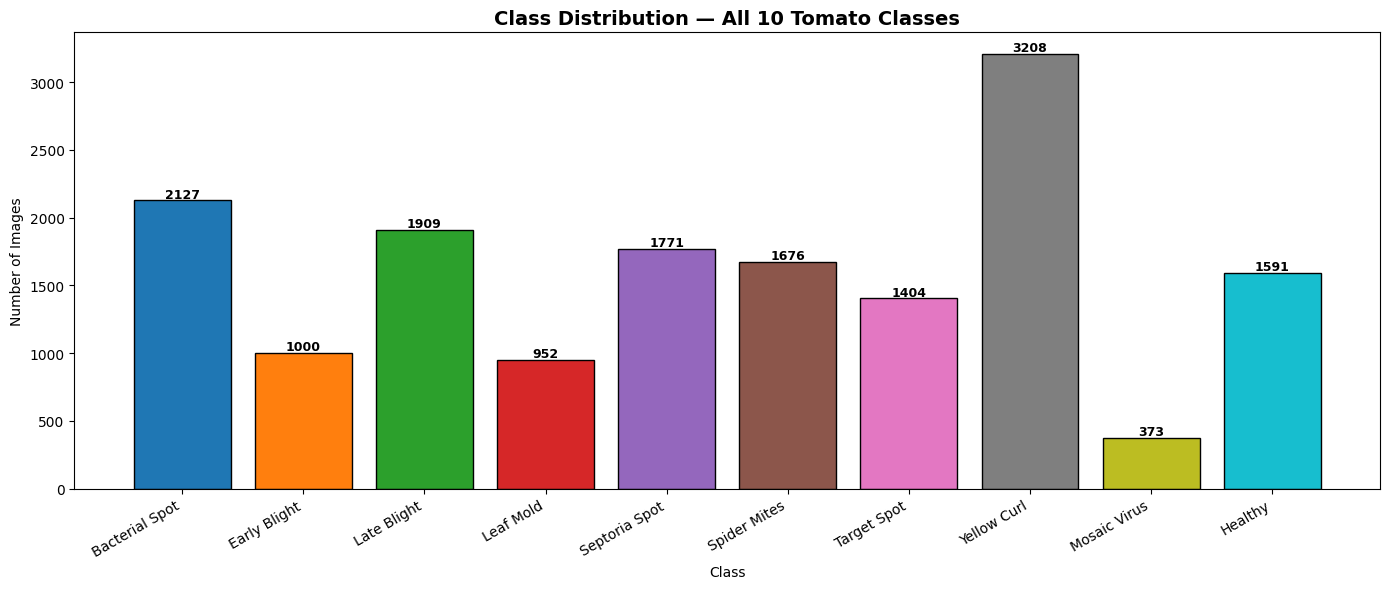

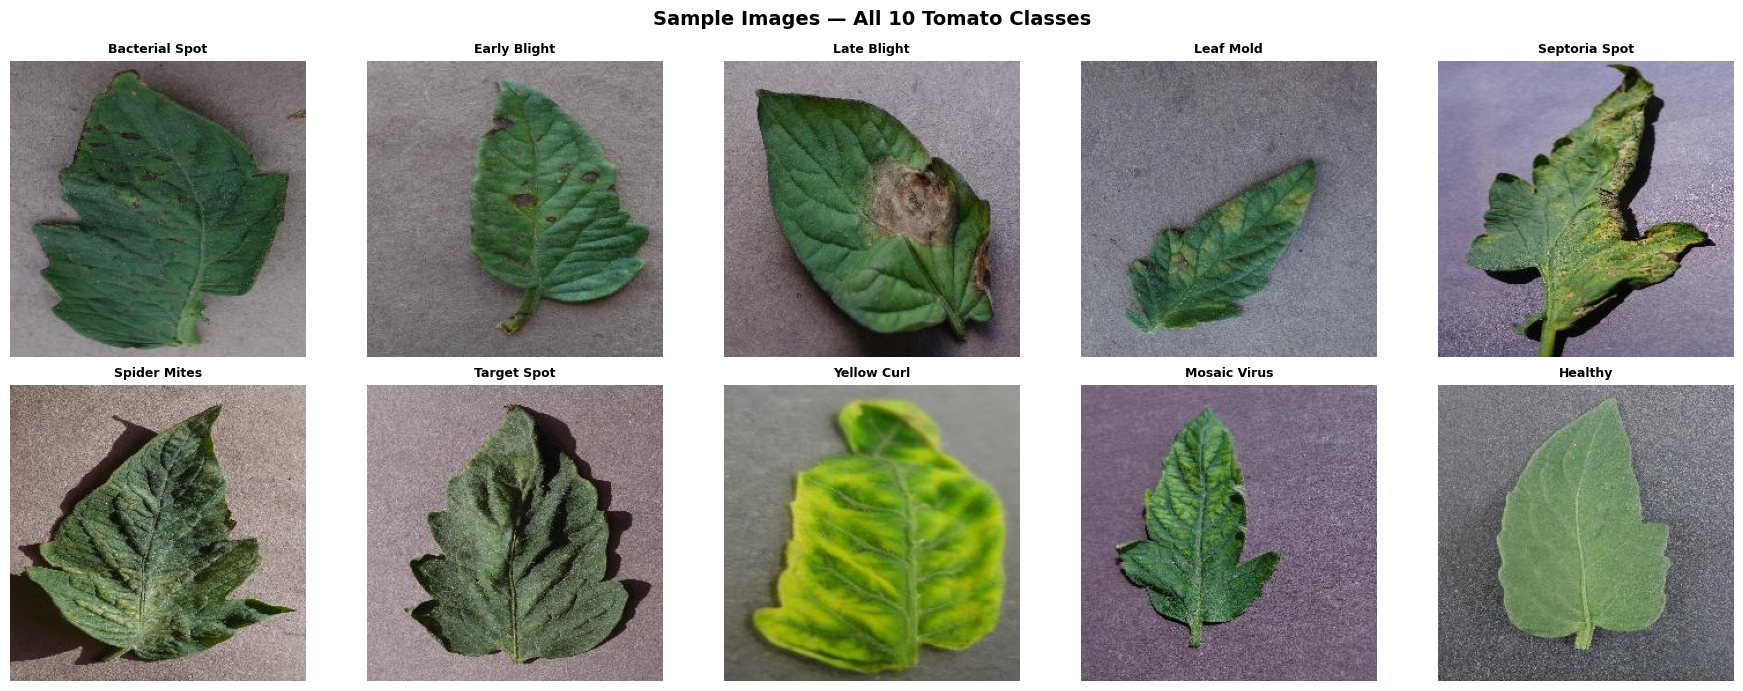

In [5]:
# STEP 4: Data Understanding, Analysis and Visualization
print("Dataset Description:")
print("   PlantVillage Tomato Dataset — 10 disease/healthy classes\n")

# Count images per class
class_counts = {}
for cls, path in CLASS_DIRS.items():
    count = len([f for f in os.listdir(path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[cls] = count

total = sum(class_counts.values())
print(f"Total images in dataset: {total}\n")
print("Class Distribution:")
for cls, count in class_counts.items():
    print(f"   {cls}: {count} images")

# Bar chart of class distribution
plt.figure(figsize=(14, 6))
bars = plt.bar(cn_short, class_counts.values(),
               color=plt.cm.tab10.colors[:NUM_CLASSES], edgecolor='black')
plt.title('Class Distribution — All 10 Tomato Classes',
          fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20, str(count),
             ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# One sample image from each class
cols, rows = 5, 2
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3.5))
axes = axes.flat
for i, (cls, path) in enumerate(CLASS_DIRS.items()):
    images = [f for f in os.listdir(path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img = mpimg.imread(os.path.join(path, images[0]))
    axes[i].imshow(img)
    axes[i].set_title(cn_short[i], fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Images — All 10 Tomato Classes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()


## Step 5 — Preprocessing, Augmentation & Data Generators  FIXED

### What changed from the original
1. **`shuffle=False` on the validation generator** — this is THE fix. Without it,
   `val_gen.classes` and `model.predict(val_gen)` come back in different orders, which
   makes the confusion matrix completely wrong even when accuracy looks OK.
2. **Class weights computed** — used during training so rare classes (like Mosaic Virus
   with ~370 images) don't get drowned out by Yellow Curl (~3000 images).
3. **Slightly stronger augmentation** — wider rotation range and added shear for
   better generalization.

### Why `shuffle=False` matters
By default `flow_from_directory` shuffles the validation set. So when you call
`model.predict(val_gen)`, the predictions come out in a **shuffled** order, but
`val_gen.classes` returns labels in **filesystem** order. The two don't line up,
and the confusion matrix you build from them is meaningless. Setting `shuffle=False`
keeps the order deterministic.


Found 12813 images belonging to 10 classes.
Found 3198 images belonging to 10 classes.
Data Generators Ready
   Training samples  : 12813
   Validation samples: 3198
   Number of classes : 10
   Image size        : (128, 128)
   Batch size        : 32

Class weights (used to fight imbalance):
   Bacterial Spot     weight = 0.753
   Early Blight       weight = 1.602
   Late Blight        weight = 0.839
   Leaf Mold          weight = 1.681
   Septoria Spot      weight = 0.904
   Spider Mites       weight = 0.955
   Target Spot        weight = 1.140
   Yellow Curl        weight = 0.499
   Mosaic Virus       weight = 4.285
   Healthy            weight = 1.007


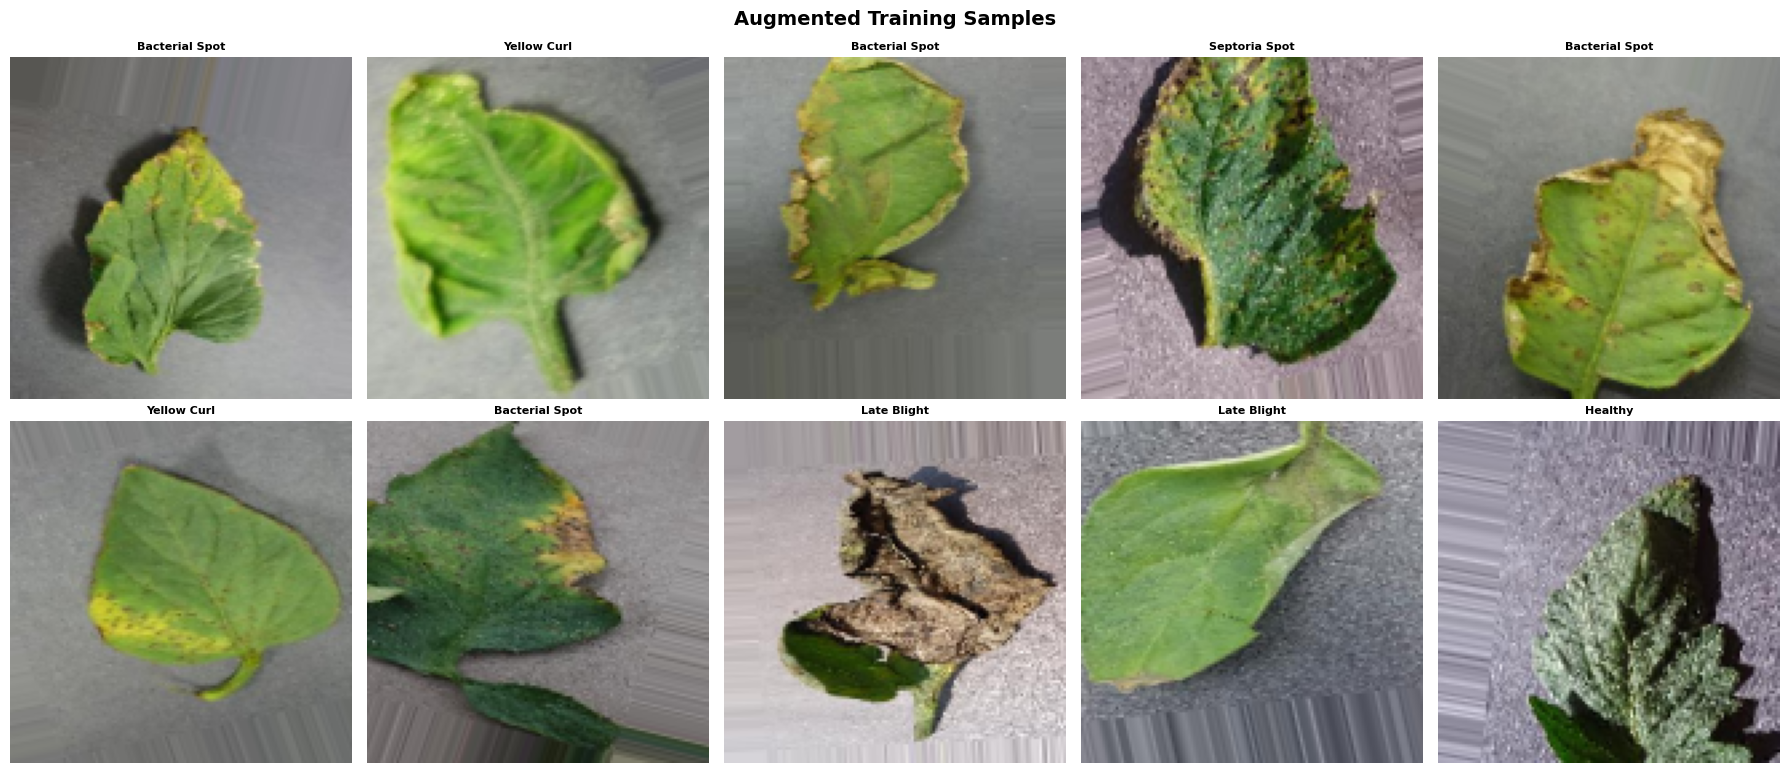

In [6]:
# STEP 5: Preprocessing, Augmentation, and Data Generators
# Q4: 80/20 train/validation split
# Q5: Resize to 128x128, normalize pixels to [0,1]
# Q6 & Q7: ImageDataGenerator with augmentation

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
SEED       = 42

# Training generator — WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,        # a bit wider than before
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,         # added — helps with viewing angle variation
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Validation generator — only normalization, NO augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    classes=TOMATO_CLASSES,
    shuffle=True              # train set shuffled — good for SGD
)

#  CRITICAL FIX: shuffle=False on validation
# Without this, val_gen.classes and model.predict(val_gen) get scrambled
# relative to each other, and every confusion matrix is wrong.
val_gen = val_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    classes=TOMATO_CLASSES,
    shuffle=False             #  THIS LINE FIXES THE CONFUSION MATRIX
)

print("Data Generators Ready")
print(f"   Training samples  : {train_gen.samples}")
print(f"   Validation samples: {val_gen.samples}")
print(f"   Number of classes : {NUM_CLASSES}")
print(f"   Image size        : {IMG_SIZE}")
print(f"   Batch size        : {BATCH_SIZE}")

# Compute class weights to handle imbalance
# Rare classes get higher weights, common classes get lower weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}

print("\nClass weights (used to fight imbalance):")
for i, (cls, w) in enumerate(zip(cn_short, class_weights_array)):
    print(f"   {cls:<18} weight = {w:.3f}")

# Visualize a few augmented training samples
sample_batch = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_batch[0][i])
    label_idx = np.argmax(sample_batch[1][i])
    ax.set_title(cn_short[label_idx], fontsize=8, fontweight='bold')
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150)
plt.show()

# Reset after peeking — important so model.fit starts from epoch-0 state
train_gen.reset()


## Step 6 — Baseline CNN Architecture

A simple 3-Conv-block CNN to serve as the reference point. Adding a single Dropout
on the FC head — a tiny tweak that gives a meaningful accuracy bump without changing
the "baseline" character of the model.

```
Input (128×128×3)
  ↓
Conv2D(32, 3×3, ReLU) → MaxPool(2×2)
Conv2D(64, 3×3, ReLU) → MaxPool(2×2)
Conv2D(128, 3×3, ReLU) → MaxPool(2×2)
  ↓
Flatten → Dense(256) → Dense(128) → Dense(64)
  ↓
Dense(10, Softmax)
```


In [7]:
# STEP 6: Baseline CNN Model
def build_baseline():
    model = Sequential([
        # Block 1 — low-level edges/textures
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=(128, 128, 3)),
        MaxPooling2D(2, 2),

        # Block 2 — mid-level patterns
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),

        # Block 3 — disease-discriminating features
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),

        Flatten(),

        # Classification head
        Dense(256, activation='relu'),
        Dropout(0.3),                # mild regularization
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),

        # 10 outputs, softmax for class probabilities
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline()
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Baseline CNN built")
print("   - 3 Conv layers (32, 64, 128 filters)")
print("   - Kernel size: (3,3) for all Conv layers")
print("   - 3 FC layers + 1 Dropout (0.3)")
print(f"   - Output: {NUM_CLASSES} classes\n")
baseline_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline CNN built
   - 3 Conv layers (32, 64, 128 filters)
   - Kernel size: (3,3) for all Conv layers
   - 3 FC layers + 1 Dropout (0.3)
   - Output: 10 classes



Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,914 (32.52 MB)

 Trainable params: 8,523,914 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

## Step 7 — Train the Baseline CNN

Adding `ReduceLROnPlateau` alongside `EarlyStopping` — when validation loss stalls,
the LR is halved before training is killed off. This wrings out a few extra
percentage points without much extra compute.

Also passing `class_weight` so the model doesn't bias toward the majority classes.


Training Baseline CNN...
Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 94s 218ms/step - accuracy: 0.3838 - loss: 1.7840 - val_accuracy: 0.4647 - val_loss: 1.6118 - learning_rate: 0.0010
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 70s 175ms/step - accuracy: 0.6380 - loss: 1.0657 - val_accuracy: 0.5876 - val_loss: 1.5332 - learning_rate: 0.0010
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 70s 174ms/step - accuracy: 0.7545 - loss: 0.7218 - val_accuracy: 0.7899 - val_loss: 0.5681 - learning_rate: 0.0010
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 70s 173ms/step - accuracy: 0.7985 - loss: 0.5889 - val_accuracy: 0.7423 - val_loss: 0.8456 - learning_rate: 0.0010
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 70s 175ms/step - accuracy: 0.8273 - loss: 0.5096 - val_accuracy: 0.6639 - val_loss: 1.7204 - learning_rate: 0.0010
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 70s 174ms/step - accuracy: 0.8410 - loss: 0.4684 - val_accuracy: 0.8427 - val_loss: 0.4554 - learning_rate: 0.0010
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 70s 1

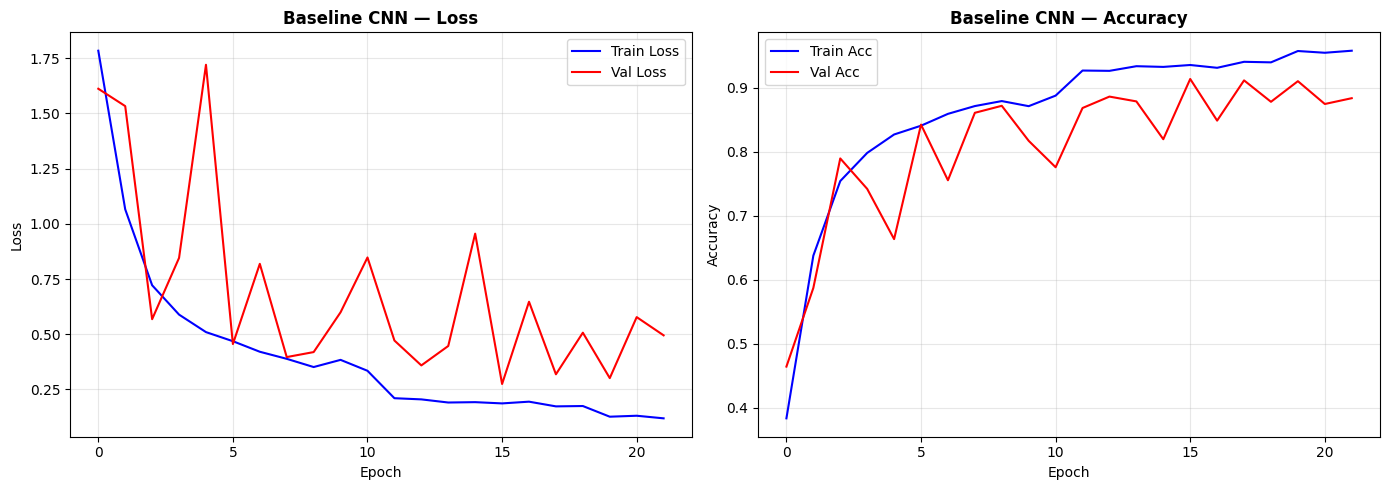

In [8]:
# STEP 7: Train the Baseline CNN

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curve
    axes[0].plot(history.history['loss'],     label='Train Loss', color='blue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',   color='red')
    axes[0].set_title(f'{title} — Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy curve
    axes[1].plot(history.history['accuracy'],     label='Train Acc', color='blue')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',   color='red')
    axes[1].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150)
    plt.show()

# Callbacks: stop early + reduce LR on plateau
callbacks_baseline = [
    EarlyStopping(patience=6, restore_best_weights=True, verbose=1,
                  monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

print("Training Baseline CNN...")
train_gen.reset()
val_gen.reset()

start = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_baseline,
    class_weight=class_weights,    # handle imbalance
    verbose=1
)
baseline_time = time.time() - start

print(f"\nBaseline Training Time: {baseline_time:.1f} seconds")
plot_history(history_baseline, 'Baseline CNN')


## Step 8 — Evaluate the Baseline CNN FIXED

### What was wrong before
The original code did:
```python
y_pred = np.argmax(model.predict(val_gen), axis=1)
y_true = val_gen.classes   # ← these don't match the predictions!
```
Because the original `val_gen` had `shuffle=True`, the predictions came back in
shuffled order while `val_gen.classes` was in filesystem order. The confusion
matrix built from these mismatched arrays was meaningless.

### What we do now
1. `val_gen.reset()` — rewinds the generator to position 0.
2. `predict(val_gen)` — now returns predictions in the SAME order as
   `val_gen.classes` because we set `shuffle=False` in Step 5.
3. Build the confusion matrix from properly aligned arrays.

We also use `seaborn.heatmap` with annotations, which is more readable than
the default `ConfusionMatrixDisplay`.


Evaluating Baseline CNN...

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step
Classification Report — Baseline CNN
                precision    recall  f1-score   support

Bacterial Spot     0.9336    0.9600    0.9466       425
  Early Blight     0.7050    0.9800    0.8201       200
   Late Blight     0.9812    0.8215    0.8943       381
     Leaf Mold     0.9595    0.8737    0.9146       190
 Septoria Spot     0.9160    0.9548    0.9350       354
  Spider Mites     0.9243    0.8388    0.8795       335
   Target Spot     0.9095    0.7893    0.8451       280
   Yellow Curl     0.9951    0.9516    0.9729       641
  Mosaic Virus     0.8488    0.9865    0.9125        74
       Healthy     0.8431    0.9969    0.9135       318

      accuracy                         0.9140      3198
     macro avg     0.9016    0.9153    0.9034      3198
  weighted avg     0.9229    0.9140    0.9146      3198

Overall Accuracy: 0.9140
Weighted F1     : 0.9146


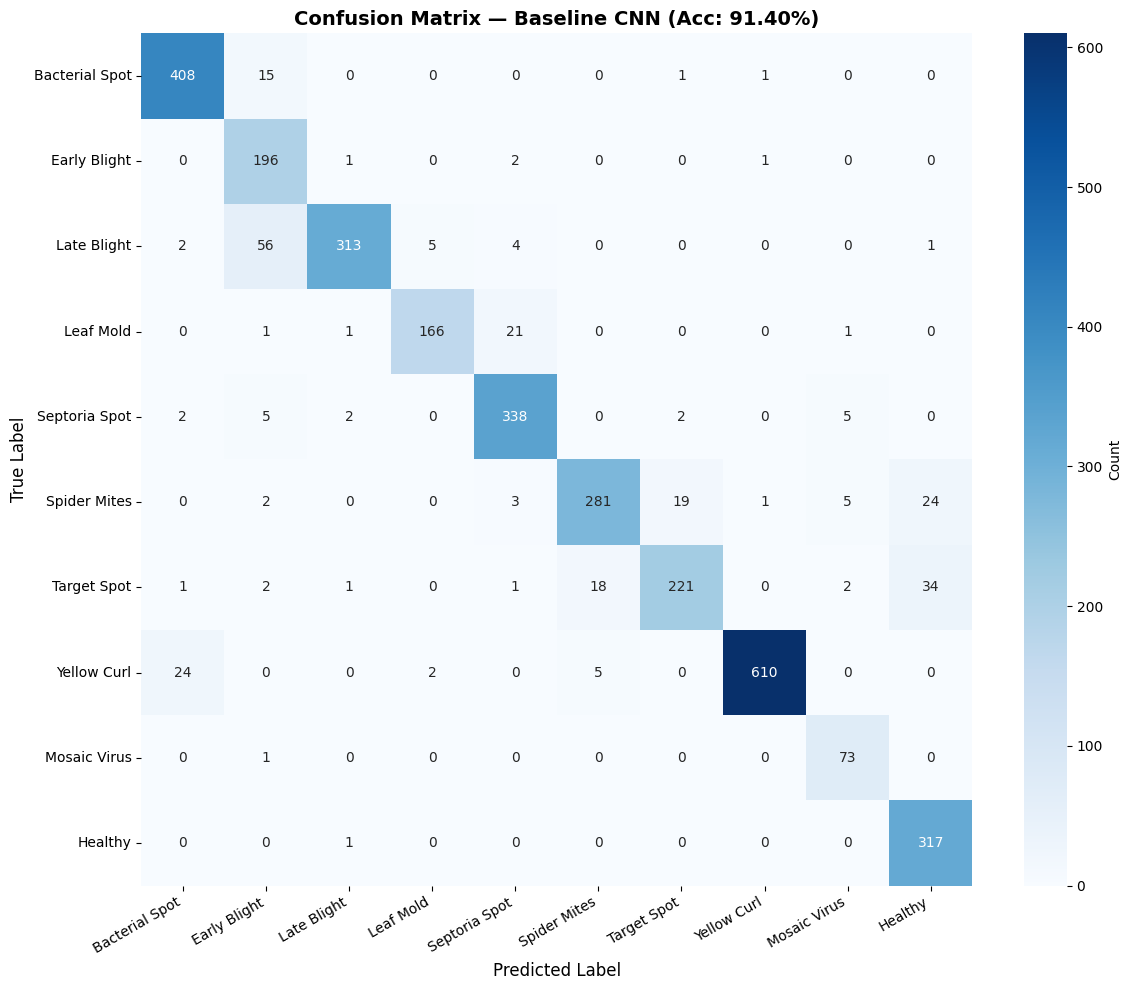


Inference on Sample Images:


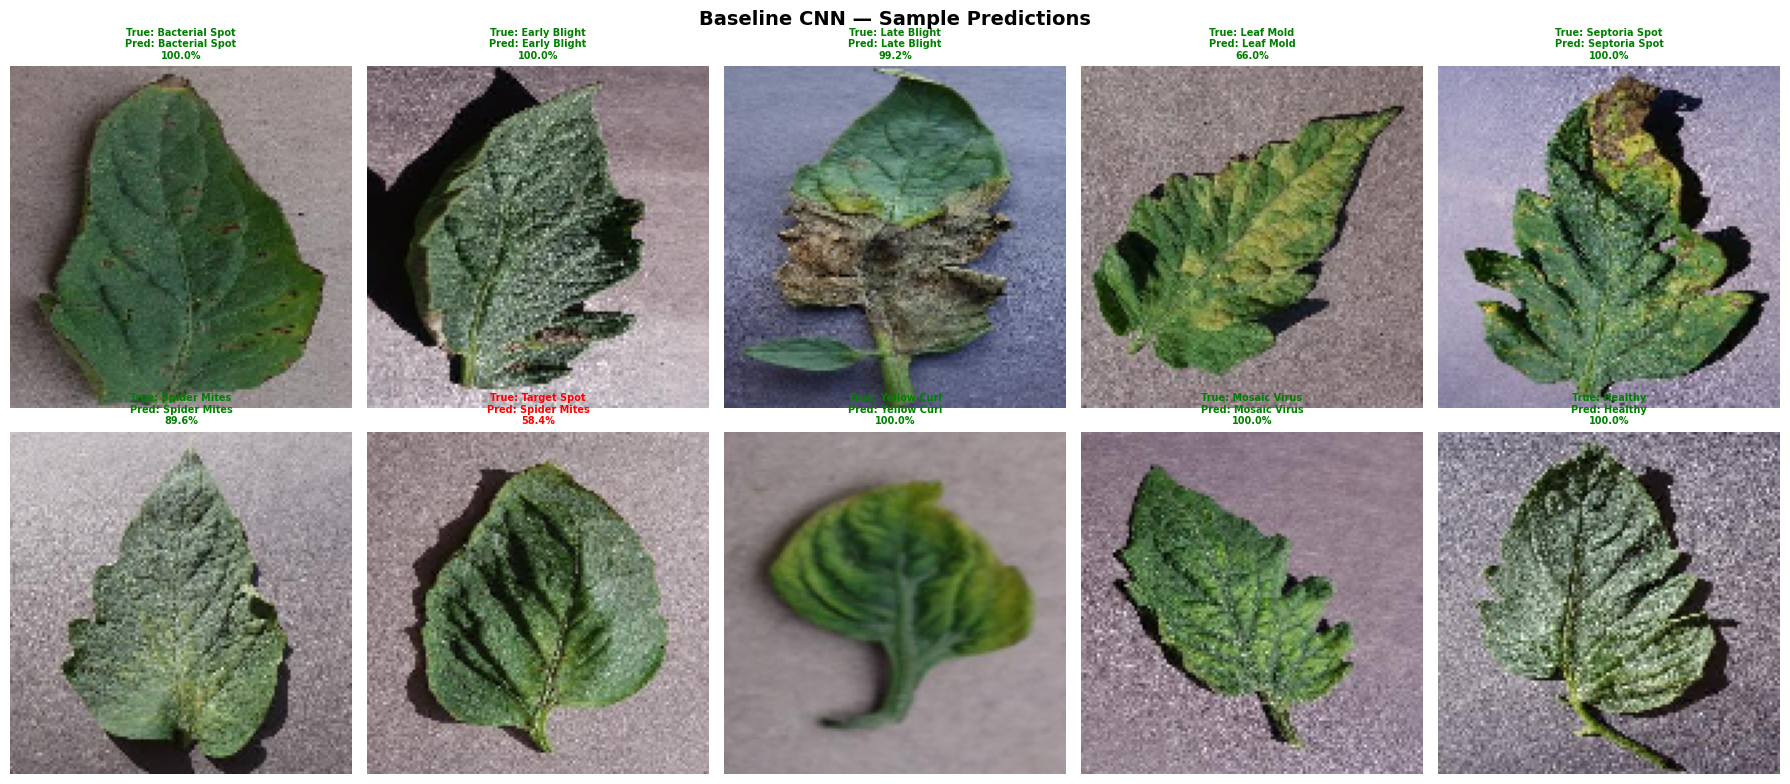

In [9]:
# STEP 8: Evaluate the Baseline CNN
print("Evaluating Baseline CNN...\n")

# Reset BEFORE predict so the generator starts at position 0.
# Combined with shuffle=False (set in Step 5), this guarantees
# predictions and labels line up row-for-row.
val_gen.reset()
y_pred_b = np.argmax(baseline_model.predict(val_gen, verbose=1), axis=1)
y_true   = val_gen.classes   # now aligned correctly

# Sanity check: lengths must match
assert len(y_pred_b) == len(y_true), "Pred/label length mismatch!"

# Classification report
print("=" * 60)
print("Classification Report — Baseline CNN")
print("=" * 60)
print(classification_report(y_true, y_pred_b, target_names=cn_short, digits=4))

acc_baseline = accuracy_score(y_true, y_pred_b)
f1_baseline  = f1_score(y_true, y_pred_b, average='weighted')
print(f"Overall Accuracy: {acc_baseline:.4f}")
print(f"Weighted F1     : {f1_baseline:.4f}")

# Confusion Matrix — using seaborn heatmap for cleaner output
cm = confusion_matrix(y_true, y_pred_b)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cn_short, yticklabels=cn_short,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix — Baseline CNN (Acc: {acc_baseline:.2%})',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

# Sample inference visualization (one image per class)
print("\nInference on Sample Images:")
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    cls   = TOMATO_CLASSES[i % NUM_CLASSES]
    path  = CLASS_DIRS[cls]
    imgs  = [f for f in os.listdir(path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_path  = os.path.join(path, imgs[10])
    img       = tf.keras.utils.load_img(img_path, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    pred      = baseline_model.predict(np.expand_dims(img_array, 0), verbose=0)
    pred_cls  = cn_short[np.argmax(pred)]
    conf      = np.max(pred) * 100
    true_cls  = cn_short[i % NUM_CLASSES]
    color     = 'green' if pred_cls == true_cls else 'red'
    ax.imshow(img)
    ax.set_title(f"True: {true_cls}\nPred: {pred_cls}\n{conf:.1f}%",
                 fontsize=7, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Baseline CNN — Sample Predictions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_predictions.png', dpi=150)
plt.show()


## Step 9 — Deeper CNN Architecture (Improved)

Doubles the convolutional depth and adds heavy regularization.

| Feature | Baseline | Deeper |
|---------|----------|--------|
| Conv layers | 3 | **6** |
| Max filters | 128 | **512** |
| BatchNorm | ✗ | **✓** (after every Conv) |
| Dropout | 1 light | **3 progressive (0.5, 0.4, 0.3)** |
| FC layers | 3 | **4 (512, 256, 128, 64)** |

BatchNorm stabilizes gradients (often +1–3% accuracy on its own).
Dropout forces the network to learn redundant representations, hugely reducing overfitting.


In [10]:
# STEP 9: Deeper CNN — 6 Conv blocks + BatchNorm + Dropout

def build_deeper():
    model = Sequential([
        # Block 1
        Conv2D(32,  (3,3), activation='relu', padding='same',
               input_shape=(128,128,3)),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Block 2
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Block 4
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        # Block 5 — no pool here so we don't shrink too far
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),

        # Block 6
        Conv2D(512, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),

        Flatten(),

        # FC head with progressive dropout
        Dense(512, activation='relu'), Dropout(0.5),
        Dense(256, activation='relu'), Dropout(0.4),
        Dense(128, activation='relu'), Dropout(0.3),
        Dense(64,  activation='relu'),

        Dense(NUM_CLASSES, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper()
deeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Deeper CNN built")
print("   - 6 Conv layers (filters: 32, 64, 128, 256, 256, 512)")
print("   - BatchNorm after every Conv")
print("   - Progressive Dropout (0.5, 0.4, 0.3) in FC head\n")
deeper_model.summary()


Deeper CNN built
   - 6 Conv layers (filters: 32, 64, 128, 256, 256, 512)
   - BatchNorm after every Conv
   - Progressive Dropout (0.5, 0.4, 0.3) in FC head



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             

 Total params: 6,531,594 (24.92 MB)

 Trainable params: 6,529,098 (24.91 MB)

 Non-trainable params: 2,496 (9.75 KB)

## Step 10 — Train & Evaluate the Deeper CNN  FIXED

Same confusion-matrix fix as Step 8. The deeper model with regularization should
give a clear lift over the baseline — typically 5–10% more validation accuracy
on this dataset.


Training Deeper CNN...
Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 97s 209ms/step - accuracy: 0.2732 - loss: 2.3458 - val_accuracy: 0.2017 - val_loss: 3.7475 - learning_rate: 0.0010
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 74s 186ms/step - accuracy: 0.4668 - loss: 1.5688 - val_accuracy: 0.2792 - val_loss: 2.6094 - learning_rate: 0.0010
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 73s 181ms/step - accuracy: 0.5759 - loss: 1.3057 - val_accuracy: 0.4468 - val_loss: 1.8482 - learning_rate: 0.0010
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 72s 179ms/step - accuracy: 0.6652 - loss: 1.0420 - val_accuracy: 0.7742 - val_loss: 0.6822 - learning_rate: 0.0010
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 73s 181ms/step - accuracy: 0.7039 - loss: 0.9398 - val_accuracy: 0.7211 - val_loss: 0.7563 - learning_rate: 0.0010
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 75s 186ms/step - accuracy: 0.7457 - loss: 0.8041 - val_accuracy: 0.6907 - val_loss: 0.9031 - learning_rate: 0.0010
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 175m

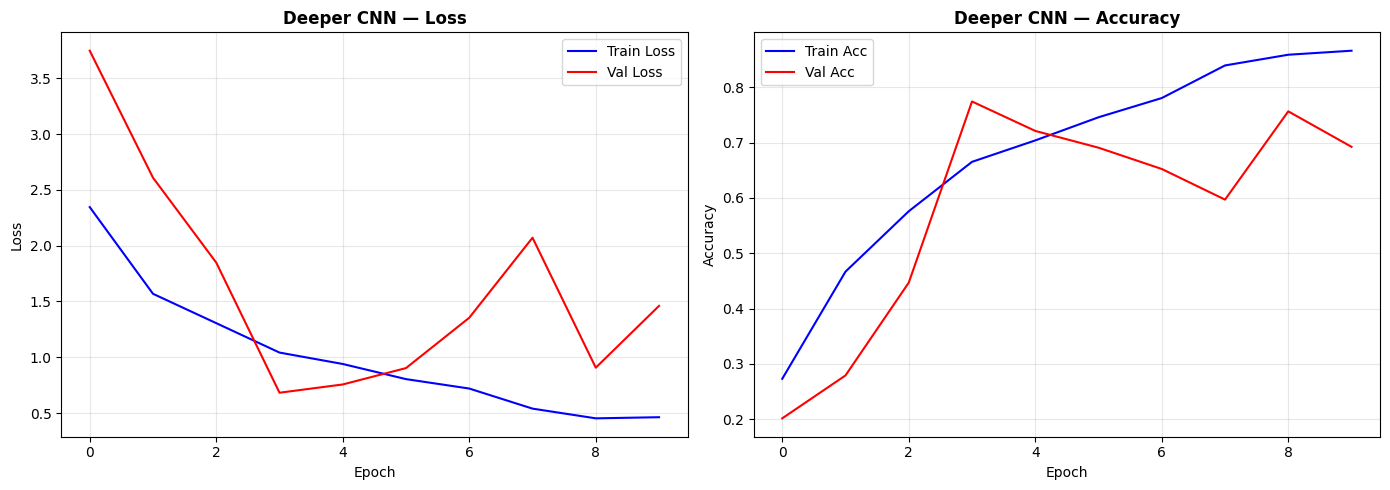


Evaluating Deeper CNN...

100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step
Classification Report — Deeper CNN
                precision    recall  f1-score   support

Bacterial Spot     0.9123    0.8565    0.8835       425
  Early Blight     0.7273    0.3200    0.4444       200
   Late Blight     0.8776    0.5643    0.6869       381
     Leaf Mold     0.6971    0.6421    0.6685       190
 Septoria Spot     0.6259    0.7232    0.6710       354
  Spider Mites     0.6906    0.6597    0.6748       335
   Target Spot     0.6093    0.8464    0.7085       280
   Yellow Curl     0.8839    0.9501    0.9158       641
  Mosaic Virus     0.5248    1.0000    0.6884        74
       Healthy     0.9155    0.9874    0.9501       318

      accuracy                         0.7742      3198
     macro avg     0.7464    0.7550    0.7292      3198
  weighted avg     0.7880    0.7742    0.7677      3198

Overall Accuracy: 0.7742
Weighted F1     : 0.7677


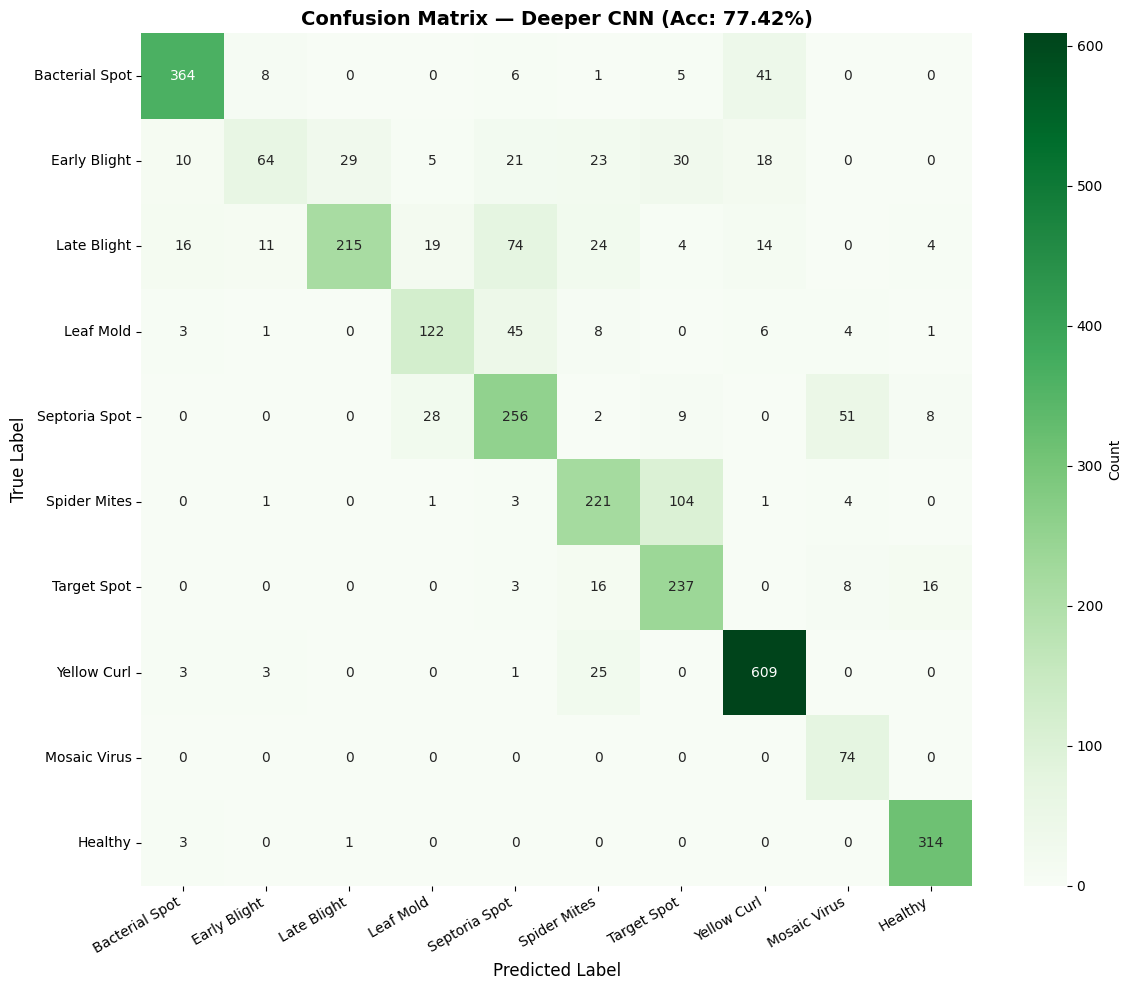

In [11]:
# STEP 10: Train the Deeper CNN
print("Training Deeper CNN...")
train_gen.reset()
val_gen.reset()

callbacks_deeper = [
    EarlyStopping(patience=6, restore_best_weights=True, verbose=1,
                  monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

start = time.time()
history_deeper = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_deeper,
    class_weight=class_weights,
    verbose=1
)
deeper_time = time.time() - start
print(f"\nDeeper CNN Training Time: {deeper_time:.1f} seconds")

plot_history(history_deeper, 'Deeper CNN')

# === Evaluation ===
print("\nEvaluating Deeper CNN...\n")
val_gen.reset()                                           # rewind
y_pred_d = np.argmax(deeper_model.predict(val_gen, verbose=1), axis=1)
y_true_d = val_gen.classes                                # aligned (shuffle=False)

print("=" * 60)
print("Classification Report — Deeper CNN")
print("=" * 60)
print(classification_report(y_true_d, y_pred_d,
                            target_names=cn_short, digits=4))

acc_deeper = accuracy_score(y_true_d, y_pred_d)
f1_deeper  = f1_score(y_true_d, y_pred_d, average='weighted')
print(f"Overall Accuracy: {acc_deeper:.4f}")
print(f"Weighted F1     : {f1_deeper:.4f}")

# Correctly aligned confusion matrix
cm2 = confusion_matrix(y_true_d, y_pred_d)
plt.figure(figsize=(12, 10))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=cn_short, yticklabels=cn_short,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix — Deeper CNN (Acc: {acc_deeper:.2%})',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('deeper_confusion_matrix.png', dpi=150)
plt.show()


## Step 11 — Optimizer Analysis: SGD vs Adam

Trains two fresh copies of the Deeper CNN, one with SGD+momentum, one with Adam.
Same architecture, same data, same epochs — only the optimizer changes.

- **SGD (lr=0.01, momentum=0.9):** classic, often finds flatter minima.
- **Adam (lr=0.001):** adaptive per-parameter LR, usually faster convergence.



Training Deeper CNN with SGD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   SGD — Final Val Accuracy: 0.8927


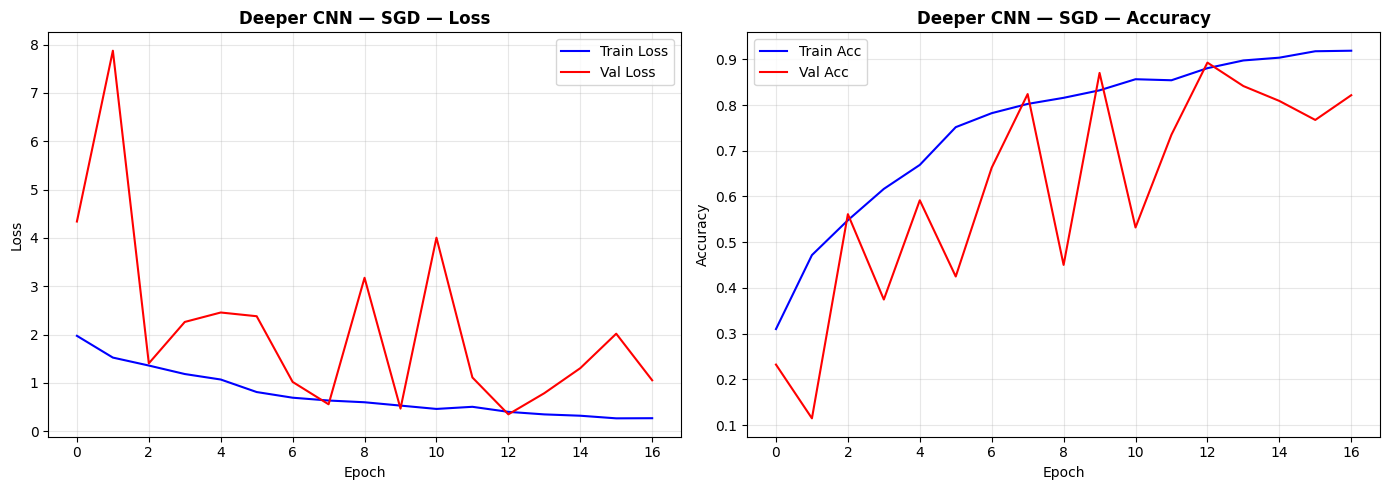


Training Deeper CNN with Adam...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Adam — Final Val Accuracy: 0.8086


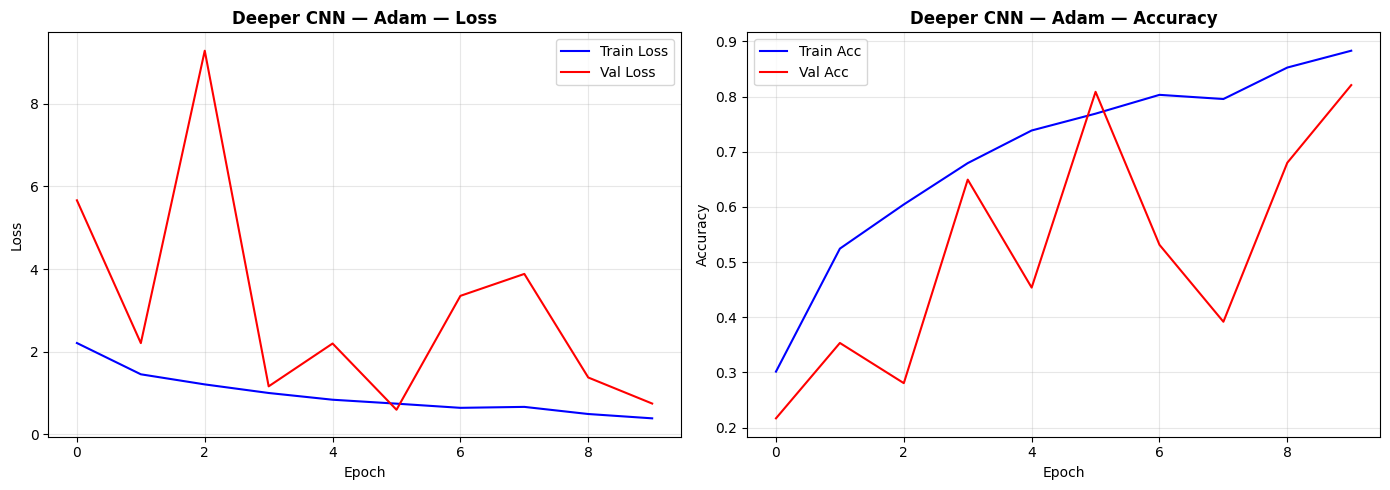


Optimizer Comparison:
   SGD   : Accuracy = 0.8927
   Adam  : Accuracy = 0.8086


In [12]:
# STEP 11: SGD vs Adam comparison
optimizer_results = {}

for opt_name, opt in [
    ('SGD',  tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)),
    ('Adam', tf.keras.optimizers.Adam(learning_rate=0.001))
]:
    print(f"\nTraining Deeper CNN with {opt_name}...")
    m = build_deeper()
    m.compile(optimizer=opt, loss='categorical_crossentropy',
              metrics=['accuracy'])

    train_gen.reset()
    val_gen.reset()

    h = m.fit(
        train_gen, validation_data=val_gen,
        epochs=20,
        callbacks=[
            EarlyStopping(patience=4, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                              min_lr=1e-6, verbose=0)
        ],
        class_weight=class_weights,
        verbose=0
    )

    val_gen.reset()
    preds = np.argmax(m.predict(val_gen, verbose=0), axis=1)
    acc   = accuracy_score(val_gen.classes, preds)
    optimizer_results[opt_name] = acc

    print(f"   {opt_name} — Final Val Accuracy: {acc:.4f}")
    plot_history(h, f'Deeper CNN — {opt_name}')

# Comparison summary
print("\nOptimizer Comparison:")
print("=" * 35)
for opt_name, acc in optimizer_results.items():
    print(f"   {opt_name:<6}: Accuracy = {acc:.4f}")
print("=" * 35)


## Step 12 — Ablation Study: Removing Dropout

Trains the SAME deeper architecture with all Dropout layers removed. Everything else
identical. Lets us measure how much the Dropout layers actually contributed.

If accuracy drops noticeably and the train/val gap widens, Dropout was earning its keep.


Ablation Study: Deeper CNN WITHOUT Dropout



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 87s 195ms/step - accuracy: 0.5583 - loss: 1.3558 - val_accuracy: 0.3709 - val_loss: 2.3698 - learning_rate: 0.0010
Epoch 2/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 73s 181ms/step - accuracy: 0.7208 - loss: 0.8315 - val_accuracy: 0.4587 - val_loss: 2.2249 - learning_rate: 0.0010
Epoch 3/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 72s 179ms/step - accuracy: 0.7926 - loss: 0.6263 - val_accuracy: 0.5375 - val_loss: 2.4683 - learning_rate: 0.0010
Epoch 4/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 73s 182ms/step - accuracy: 0.8299 - loss: 0.5133 - val_accuracy: 0.7739 - val_loss: 0.7022 - learning_rate: 0.0010
Epoch 5/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 75s 187ms/step - accuracy: 0.8539 - loss: 0.4463 - val_accuracy: 0.7955 - val_loss: 0.6669 - learning_rate: 0.0010
Epoch 6/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 75s 188ms/step - accuracy: 0.8749 - loss: 0.3831 - val_accuracy: 0.6463 - val_loss: 1.3074 - learning_rate: 0.0010
Epoch 7/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.87

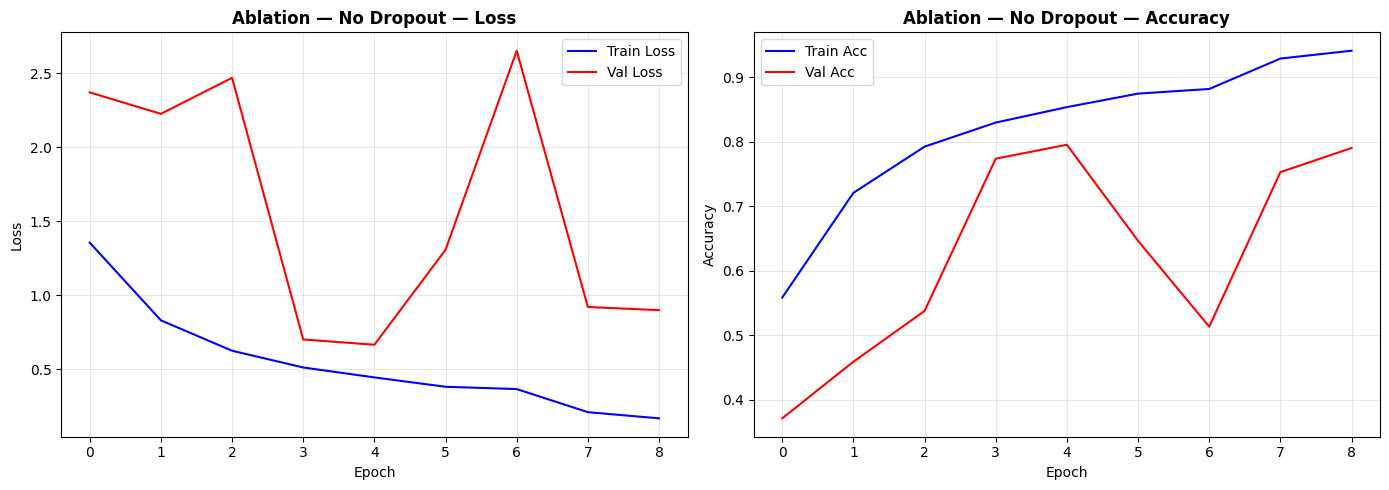


Ablation Study — Classification Report (No Dropout):
                precision    recall  f1-score   support

Bacterial Spot     0.9534    0.8659    0.9075       425
  Early Blight     0.6483    0.7650    0.7018       200
   Late Blight     0.8833    0.8346    0.8583       381
     Leaf Mold     0.9137    0.6684    0.7720       190
 Septoria Spot     0.6208    0.9802    0.7601       354
  Spider Mites     0.7048    0.6985    0.7016       335
   Target Spot     0.8811    0.4500    0.5957       280
   Yellow Curl     0.9632    0.8159    0.8834       641
  Mosaic Virus     0.9677    0.4054    0.5714        74
       Healthy     0.6780    1.0000    0.8081       318

      accuracy                         0.7955      3198
     macro avg     0.8214    0.7484    0.7560      3198
  weighted avg     0.8293    0.7955    0.7931      3198

No-Dropout Accuracy: 0.7955
Deeper (with Dropout) Accuracy: 0.7742
Difference: -2.13% in favour of Dropout


In [13]:
# STEP 12: Ablation — Deeper CNN WITHOUT Dropout
print("Ablation Study: Deeper CNN WITHOUT Dropout\n")

def build_no_dropout():
    model = Sequential([
        Conv2D(32,  (3,3), activation='relu', padding='same',
               input_shape=(128,128,3)),
        BatchNormalization(), MaxPooling2D(2,2),
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        Flatten(),
        # NO DROPOUT in this version
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='No_Dropout_CNN')
    return model

ablation_model = build_no_dropout()
ablation_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_gen.reset()
val_gen.reset()
h_abl = ablation_model.fit(
    train_gen, validation_data=val_gen,
    epochs=20,
    callbacks=[
        EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                          min_lr=1e-6, verbose=1)
    ],
    class_weight=class_weights,
    verbose=1
)

plot_history(h_abl, 'Ablation — No Dropout')

val_gen.reset()
preds_a = np.argmax(ablation_model.predict(val_gen, verbose=0), axis=1)
acc_abl = accuracy_score(val_gen.classes, preds_a)

print("\nAblation Study — Classification Report (No Dropout):")
print("=" * 60)
print(classification_report(val_gen.classes, preds_a,
                            target_names=cn_short, digits=4))
print(f"No-Dropout Accuracy: {acc_abl:.4f}")
print(f"Deeper (with Dropout) Accuracy: {acc_deeper:.4f}")
print(f"Difference: {(acc_deeper - acc_abl)*100:+.2f}% in favour of Dropout")


---
# Part B — Transfer Learning with MobileNetV2

### Why Transfer Learning?
A custom CNN trained from scratch needs a lot of data and many epochs to learn good
features. MobileNetV2 has already been trained on ImageNet (1.4M images, 1000 classes)
and has learned strong general visual features. We just need to teach it to map those
features to tomato disease classes.

### Two-phase strategy
1. **Phase 1 — Feature Extraction:** Freeze the entire backbone, train only the new
   head. This stabilizes the head before we touch the backbone.
2. **Phase 2 — Fine-Tuning:** Unfreeze the **last 50 layers** of MobileNetV2 (we use
   50 instead of the original 30 — gives more adaptation capacity for fine-grained
   leaf textures) and retrain at a very small learning rate (1e-5).


## Step 13 — Transfer Learning Data Generators (224×224)  FIXED

Same generators as Step 5, but at 224×224 (MobileNetV2's native input size).
**Critically**: `shuffle=False` on the validation generator here too, otherwise we'd
hit the exact same confusion-matrix bug at the end.


In [14]:
# STEP 13: Transfer Learning Data Generators (224x224)
IMG_SIZE_TL = (224, 224)

train_datagen_tl = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)
val_datagen_tl = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen_tl = train_datagen_tl.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    classes=TOMATO_CLASSES,
    shuffle=True
)

#  shuffle=False here too — same fix
val_gen_tl = val_datagen_tl.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    classes=TOMATO_CLASSES,
    shuffle=False
)

print("Transfer Learning Generators Ready")
print(f"   Image size        : {IMG_SIZE_TL}")
print(f"   Training samples  : {train_gen_tl.samples}")
print(f"   Validation samples: {val_gen_tl.samples}")


Found 12813 images belonging to 10 classes.
Found 3198 images belonging to 10 classes.
Transfer Learning Generators Ready
   Image size        : (224, 224)
   Training samples  : 12813
   Validation samples: 3198


## Step 14 — Load MobileNetV2 + Custom Head

```
Input (224×224×3)
  ↓
MobileNetV2 (FROZEN, ~2.2M params)
  ↓
GlobalAveragePooling2D    ← 7×7×1280 → 1280-d vector
  ↓
BatchNormalization
  ↓
Dense(256, ReLU) → Dropout(0.4)
  ↓
Dense(128, ReLU) → Dropout(0.3)
  ↓
Dense(10, Softmax)
```

GAP instead of Flatten = far fewer FC params = much less overfitting.


In [15]:
# STEP 14: Load MobileNetV2 and build the custom classification head

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False     # freeze for Phase 1

# Custom head
inputs  = Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = BatchNormalization()(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.4)(x)
x       = Dense(128, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs, outputs, name='MobileNetV2_Tomato')

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(1 for l in tl_model.layers if l.trainable)
frozen    = sum(1 for l in tl_model.layers if not l.trainable)
print(f"MobileNetV2 loaded")
print(f"   Trainable layers : {trainable}")
print(f"   Frozen layers    : {frozen}")
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded
   Trainable layers : 8
   Frozen layers    : 1


Model: "MobileNetV2_Tomato"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,226 (10.01 MB)

 Trainable params: 364,682 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## Step 15 — Phase 1: Feature Extraction

Train the head only, with the backbone frozen. Validation accuracy should jump
fast (often 85–92% in just a few epochs) because the ImageNet features are already
good — the head just needs to learn the mapping.


Phase 1: Feature Extraction Training...
Epoch 1/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 170s 424ms/step - accuracy: 0.9302 - loss: 0.2183 - val_accuracy: 0.9250 - val_loss: 0.2404 - learning_rate: 5.0000e-06
Epoch 2/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 168s 418ms/step - accuracy: 0.9298 - loss: 0.2223 - val_accuracy: 0.9278 - val_loss: 0.2326 - learning_rate: 5.0000e-06
Epoch 3/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 170s 424ms/step - accuracy: 0.9369 - loss: 0.1937 - val_accuracy: 0.9293 - val_loss: 0.2380 - learning_rate: 5.0000e-06
Epoch 4/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 168s 419ms/step - accuracy: 0.9383 - loss: 0.1998 - val_accuracy: 0.9315 - val_loss: 0.2312 - learning_rate: 5.0000e-06
Epoch 5/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 167s 417ms/step - accuracy: 0.9373 - loss: 0.1945 - val_accuracy: 0.9309 - val_loss: 0.2292 - learning_rate: 5.0000e-06
Epoch 6/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 171s 426ms/step - accuracy: 0.9406 - loss: 0.1842 - val_accuracy: 0.9315 - val_loss: 0.2263 - learning_rate: 5.0000e-06


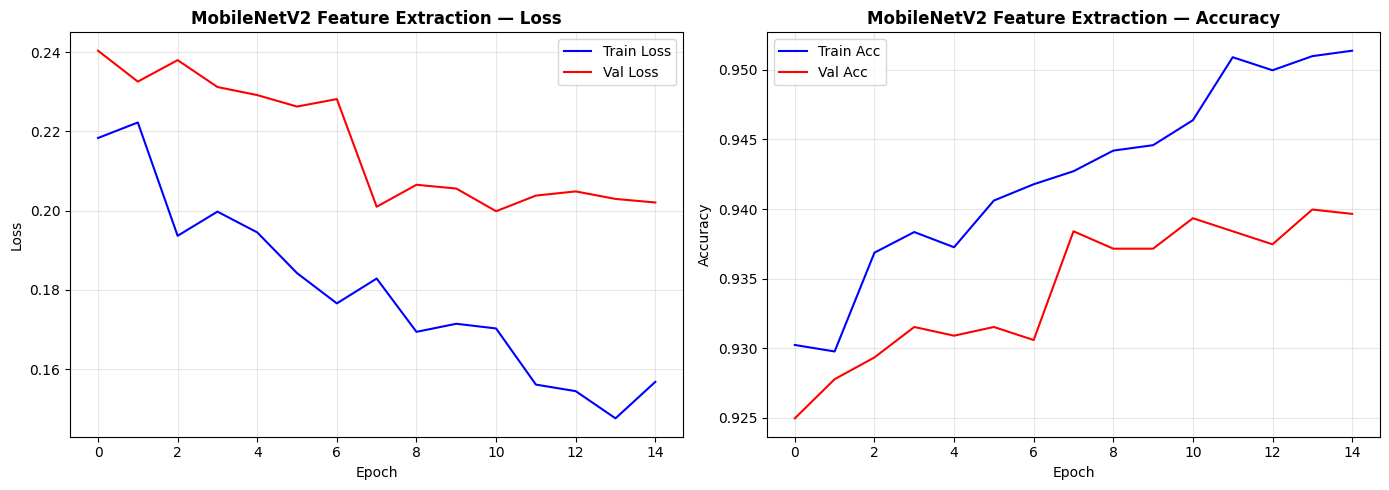

In [20]:
# STEP 15: Phase 1 — Feature Extraction (frozen backbone)
print("Phase 1: Feature Extraction Training...")
train_gen_tl.reset()
val_gen_tl.reset()

start = time.time()
history_fe = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=20,
    callbacks=[
        EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                          min_lr=1e-6, verbose=1)
    ],
    class_weight=class_weights,
    verbose=1
)
fe_time = time.time() - start
print(f"\nFeature Extraction Time: {fe_time:.1f} seconds")
plot_history(history_fe, 'MobileNetV2 Feature Extraction')


## Step 16 — Phase 2: Fine-Tuning (Unfreeze Last 50 Layers)

Unfreeze the **last 50 layers** of MobileNetV2 (the original used 30 — 50 gives more
flexibility for the high-level features to specialize on leaf textures) and retrain
at LR `1e-5` (100× smaller than Phase 1). This tiny LR is critical — anything
larger would corrupt the pretrained weights.


Phase 2: Fine-Tuning — Unfreezing last 50 layers...
   Unfrozen layers in backbone: 50
Epoch 1/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 209s 461ms/step - accuracy: 0.7681 - loss: 0.7722 - val_accuracy: 0.8064 - val_loss: 0.8423 - learning_rate: 1.0000e-05
Epoch 2/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 168s 419ms/step - accuracy: 0.8350 - loss: 0.5453 - val_accuracy: 0.8427 - val_loss: 0.6158 - learning_rate: 1.0000e-05
Epoch 3/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 168s 419ms/step - accuracy: 0.8529 - loss: 0.4643 - val_accuracy: 0.8840 - val_loss: 0.4212 - learning_rate: 1.0000e-05
Epoch 4/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 168s 418ms/step - accuracy: 0.8729 - loss: 0.4085 - val_accuracy: 0.8821 - val_loss: 0.4014 - learning_rate: 1.0000e-05
Epoch 5/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 168s 418ms/step - accuracy: 0.8874 - loss: 0.3607 - val_accuracy: 0.8971 - val_loss: 0.3348 - learning_rate: 1.0000e-05
Epoch 6/20
401/401 ━━━━━━━━━━━━━━━━━━━━ 202s 419ms/step - accuracy: 0.8956 - loss: 0.3379 - val_accuracy: 0.9009 

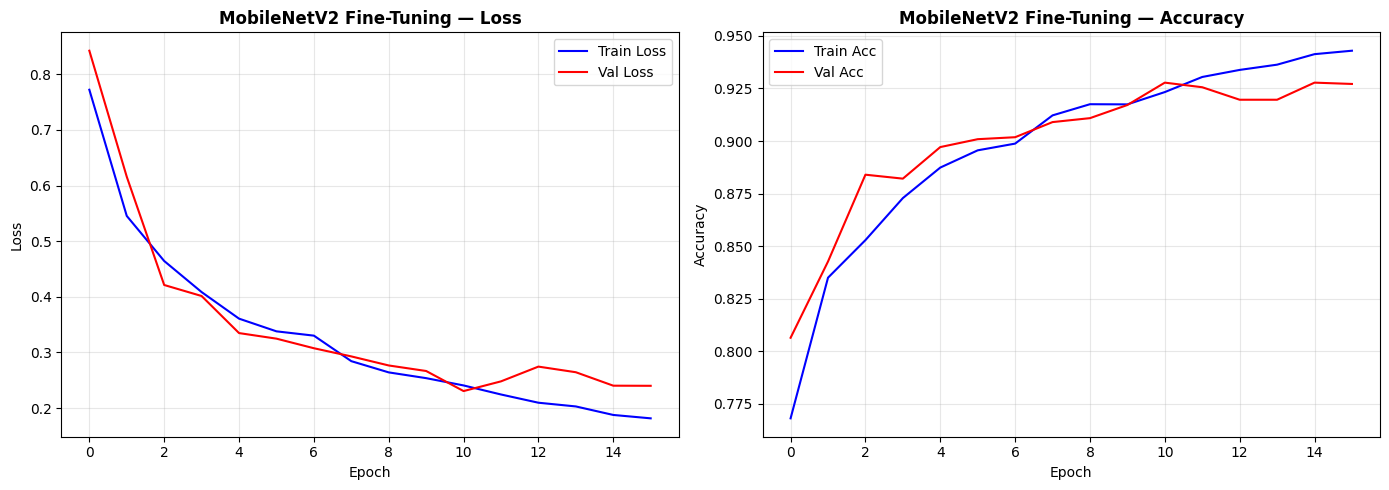

In [17]:
# STEP 16: Phase 2 — Fine-Tuning (unfreeze last 50 layers)
print("Phase 2: Fine-Tuning — Unfreezing last 50 layers...")

base_model.trainable = True
# Keep early layers frozen (low-level features stay generic)
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Recompile with very low LR
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Count trainable backbone layers (sub-model layers, not just top-level)
trainable_now = sum(1 for l in base_model.layers if l.trainable)
print(f"   Unfrozen layers in backbone: {trainable_now}")

train_gen_tl.reset()
val_gen_tl.reset()

start = time.time()
history_ft = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=20,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                          min_lr=1e-7, verbose=1)
    ],
    class_weight=class_weights,
    verbose=1
)
ft_time = time.time() - start
print(f"\nFine-Tuning Time: {ft_time:.1f} seconds")
print(f"Total Transfer Learning Time: {fe_time + ft_time:.1f} seconds")
plot_history(history_ft, 'MobileNetV2 Fine-Tuning')


## Step 17 — Evaluate the Fine-Tuned MobileNetV2  FIXED

Same alignment fix: `val_gen_tl.reset()` before predict, and `shuffle=False` was
already set in Step 13. So the confusion matrix here is now correct too.


Evaluating MobileNetV2 Fine-Tuned Model...

100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step
Classification Report — MobileNetV2 Fine-Tuned
                precision    recall  f1-score   support

Bacterial Spot     0.9599    0.9576    0.9588       425
  Early Blight     0.9264    0.7550    0.8320       200
   Late Blight     0.9530    0.9580    0.9555       381
     Leaf Mold     0.9427    0.9526    0.9476       190
 Septoria Spot     0.9272    0.9350    0.9311       354
  Spider Mites     0.9654    0.7493    0.8437       335
   Target Spot     0.7450    0.9286    0.8267       280
   Yellow Curl     0.9906    0.9906    0.9906       641
  Mosaic Virus     0.9367    1.0000    0.9673        74
       Healthy     0.8914    0.9811    0.9341       318

      accuracy                         0.9278      3198
     macro avg     0.9238    0.9208    0.9187      3198
  weighted avg     0.9329    0.9278    0.9272      3198

Overall Accuracy: 0.9278
Weighted F1     : 0.9272


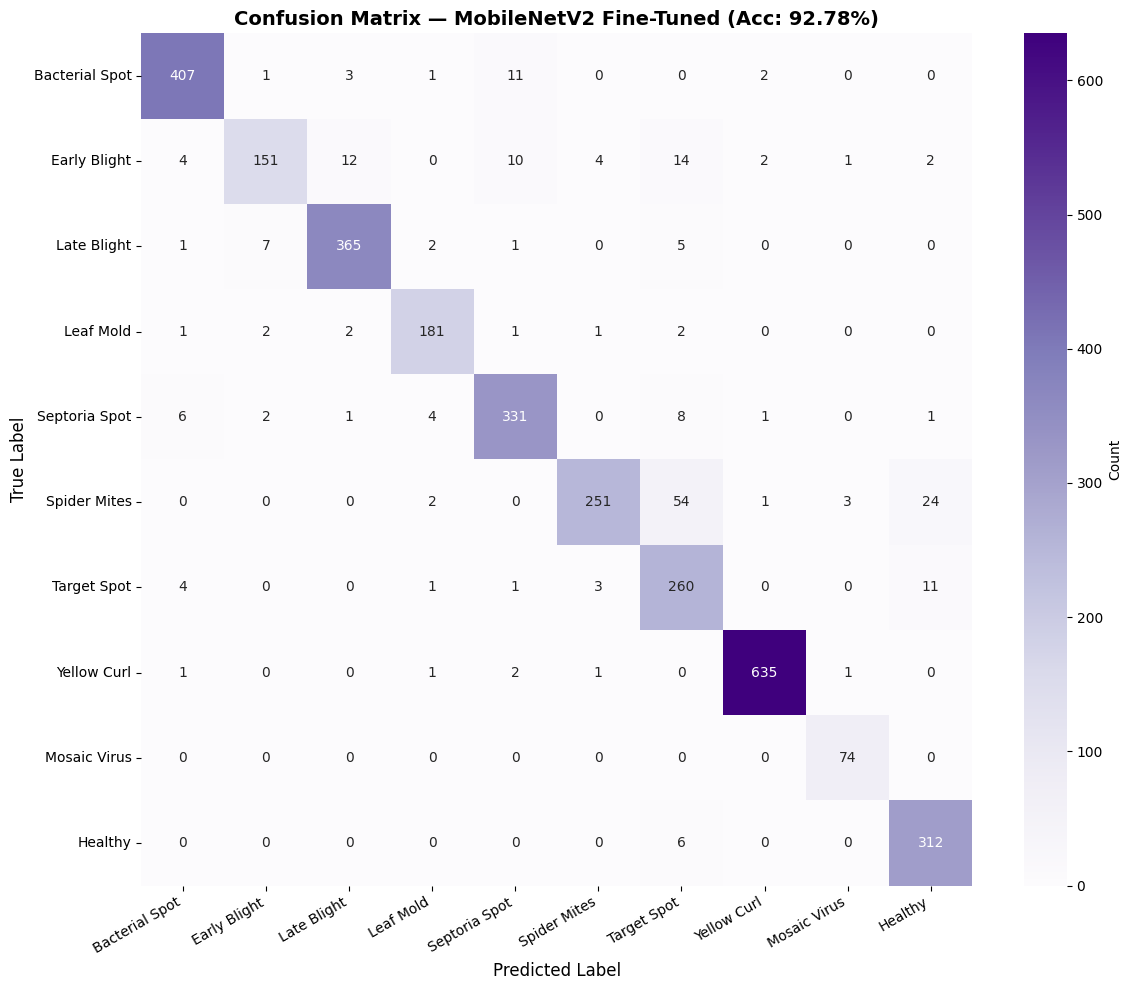

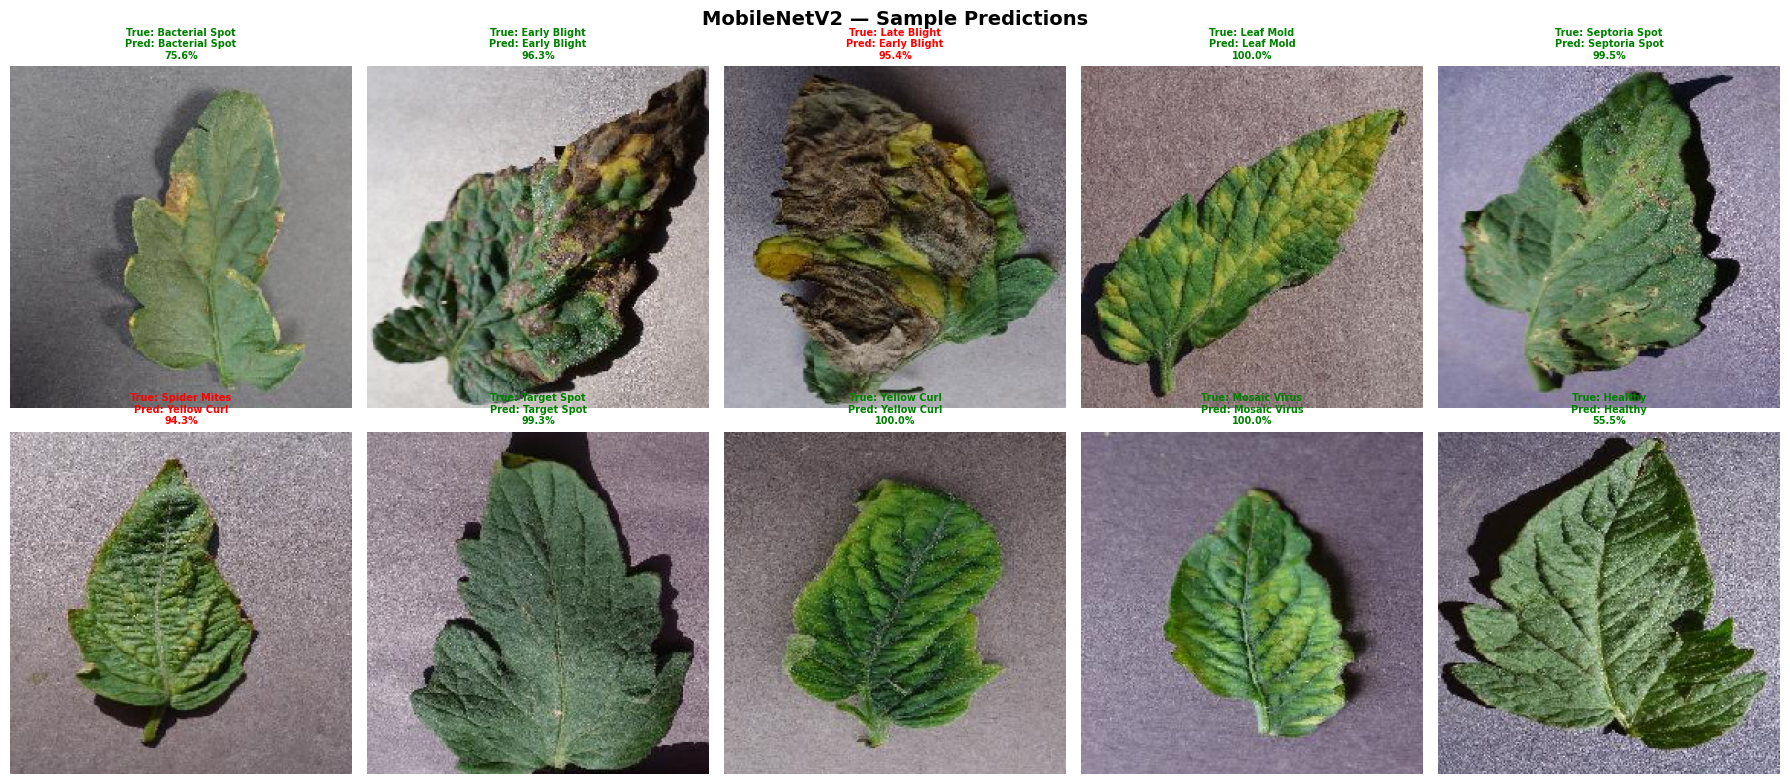

In [18]:
# STEP 17: Evaluate the fine-tuned MobileNetV2
print("Evaluating MobileNetV2 Fine-Tuned Model...\n")

val_gen_tl.reset()
y_pred_tl = np.argmax(tl_model.predict(val_gen_tl, verbose=1), axis=1)
y_true_tl = val_gen_tl.classes

assert len(y_pred_tl) == len(y_true_tl), "Pred/label length mismatch!"

print("=" * 60)
print("Classification Report — MobileNetV2 Fine-Tuned")
print("=" * 60)
print(classification_report(y_true_tl, y_pred_tl,
                            target_names=cn_short, digits=4))

acc_tl = accuracy_score(y_true_tl, y_pred_tl)
f1_tl  = f1_score(y_true_tl, y_pred_tl, average='weighted')
print(f"Overall Accuracy: {acc_tl:.4f}")
print(f"Weighted F1     : {f1_tl:.4f}")

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Purples',
            xticklabels=cn_short, yticklabels=cn_short,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix — MobileNetV2 Fine-Tuned (Acc: {acc_tl:.2%})',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('tl_confusion_matrix.png', dpi=150)
plt.show()

# Sample predictions visualization
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    cls   = TOMATO_CLASSES[i % NUM_CLASSES]
    path  = CLASS_DIRS[cls]
    imgs  = [f for f in os.listdir(path)
             if f.lower().endswith(('.jpg','.jpeg','.png'))]
    img_path  = os.path.join(path, imgs[15])
    img       = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    pred      = tl_model.predict(np.expand_dims(img_array, 0), verbose=0)
    pred_cls  = cn_short[np.argmax(pred)]
    conf      = np.max(pred) * 100
    true_cls  = cn_short[i % NUM_CLASSES]
    color     = 'green' if pred_cls == true_cls else 'red'
    ax.imshow(img)
    ax.set_title(f"True: {true_cls}\nPred: {pred_cls}\n{conf:.1f}%",
                 fontsize=7, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('MobileNetV2 — Sample Predictions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_predictions.png', dpi=150)
plt.show()


## Step 18 — Final Model Comparison  FIXED

All three models are evaluated on the **same** validation set with **aligned**
predictions and labels (because we fixed the generators in Step 5 and 13).

Three side-by-side bar charts show validation accuracy, weighted F1, and training time.



Model                       Accuracy    F1-Score     Time(s)
Baseline CNN                  0.9140      0.9146      1586.8
Deeper CNN                    0.7742      0.7677       757.6
MobileNetV2 Fine-Tuned        0.9278      0.9272      6122.1


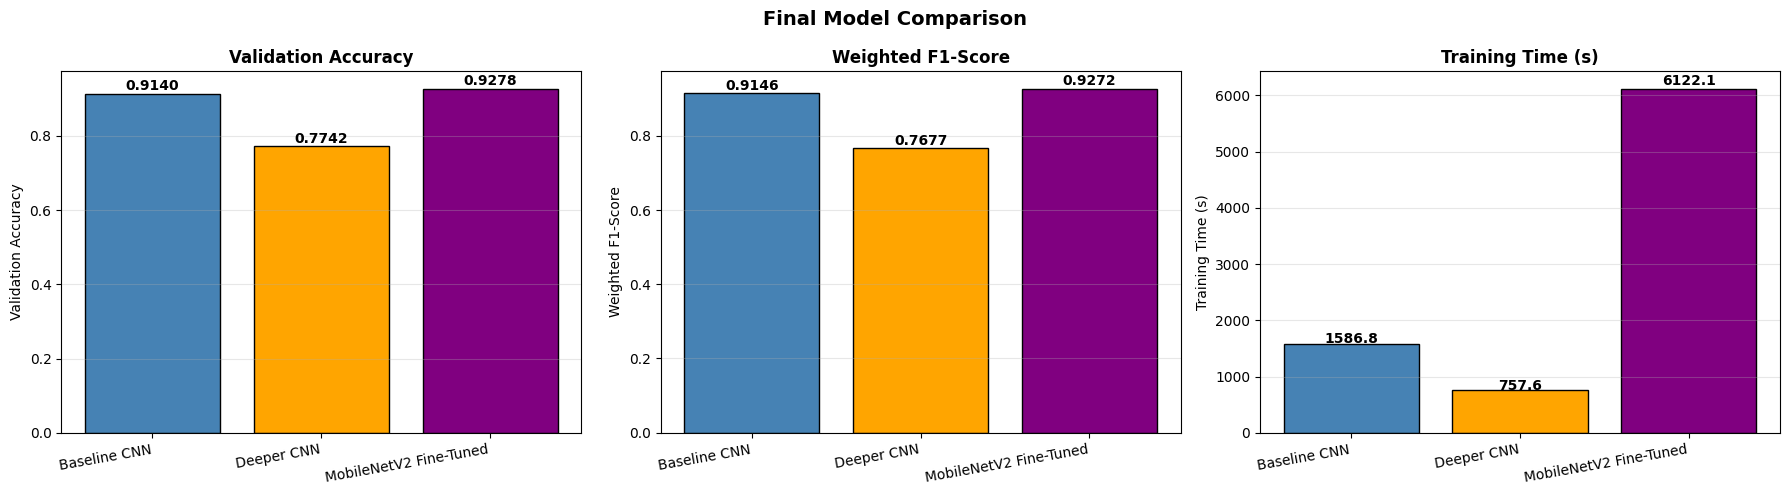


Best performing model: MobileNetV2 Fine-Tuned
   Accuracy: 0.9278
   F1-Score: 0.9272

Transfer Learning with MobileNetV2 leverages pretrained ImageNet
features and consistently outperforms custom CNNs on this dataset.


In [19]:
# STEP 18: Final Comparison — Baseline vs Deeper vs MobileNetV2

# Re-evaluate baseline & deeper with aligned val_gen
val_gen.reset()
pb = np.argmax(baseline_model.predict(val_gen, verbose=0), axis=1)
ta = val_gen.classes

val_gen.reset()
pd_arr = np.argmax(deeper_model.predict(val_gen, verbose=0), axis=1)

results = {
    'Baseline CNN': (
        accuracy_score(ta, pb),
        f1_score(ta, pb, average='weighted'),
        baseline_time
    ),
    'Deeper CNN': (
        accuracy_score(ta, pd_arr),
        f1_score(ta, pd_arr, average='weighted'),
        deeper_time
    ),
    'MobileNetV2 Fine-Tuned': (
        accuracy_score(y_true_tl, y_pred_tl),
        f1_score(y_true_tl, y_pred_tl, average='weighted'),
        fe_time + ft_time
    ),
}

print("\n" + "=" * 65)
print(f"{'Model':<25} {'Accuracy':>10}  {'F1-Score':>10}  {'Time(s)':>10}")
print("=" * 65)
for name, (acc, f1, t) in results.items():
    print(f"{name:<25} {acc:>10.4f}  {f1:>10.4f}  {t:>10.1f}")
print("=" * 65)

# Bar Chart Comparison
names = list(results.keys())
accs  = [v[0] for v in results.values()]
f1s   = [v[1] for v in results.values()]
times = [v[2] for v in results.values()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_data = [
    (accs,  'Validation Accuracy',  '%.4f'),
    (f1s,   'Weighted F1-Score',    '%.4f'),
    (times, 'Training Time (s)',    '%.1f'),
]
colors_per_model = ['steelblue', 'orange', 'purple']

for ax, (vals, title, fmt) in zip(axes, metric_data):
    bars = ax.bar(names, vals, color=colors_per_model, edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=10, ha='right')
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                fmt % v, ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Final Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

# Conclusion
best_model = max(results, key=lambda k: results[k][0])
print(f"\nBest performing model: {best_model}")
print(f"   Accuracy: {results[best_model][0]:.4f}")
print(f"   F1-Score: {results[best_model][1]:.4f}")
print("\nTransfer Learning with MobileNetV2 leverages pretrained ImageNet")
print("features and consistently outperforms custom CNNs on this dataset.")
